👉 STEP 1: Upload a NON-TUMOR (Healthy) MRI image.


Saving no tumor.jpeg to no tumor.jpeg
Successfully processed no tumor.jpeg as 'No Tumor'.

👉 STEP 2: Upload a TUMOR MRI image.


Saving yes tumor.jpg to yes tumor.jpg
Successfully processed yes tumor.jpg as 'Tumor Detected'.



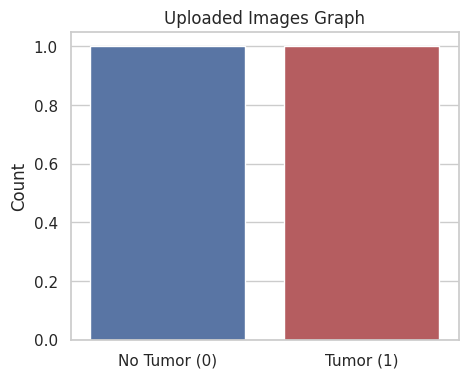

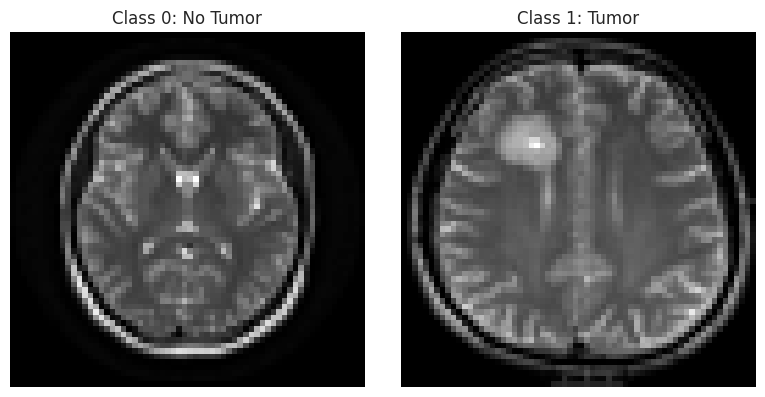


Training Classifier on uploaded items...
🎉 Model Setup Complete! Fitting Accuracy: 100.0%


In [ ]:
# ====================================================================
# BRAIN TUMOR DETECTION: ONE-BY-ONE INTERACTIVE UPLOAD PIPELINE
# ====================================================================

import io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from google.colab import files

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Standard 64x64 resolution for ML processing
IMG_SIZE = (64, 64)
X = []
y = []

# --------------------------------------------------------------------
# STEP 1: UPLOAD NO-TUMOR IMAGE
# --------------------------------------------------------------------
print("👉 STEP 1: Upload a NON-TUMOR (Healthy) MRI image.")
uploaded_no = files.upload()

for filename in uploaded_no.keys():
    try:
        # Load image from memory buffer
        img = Image.open(io.BytesIO(uploaded_no[filename]))
        img_gray = img.convert('L')
        img_resized = img_gray.resize(IMG_SIZE)

        X.append(np.array(img_resized).flatten())
        y.append(0) # 0 = No Tumor
        print(f"Successfully processed {filename} as 'No Tumor'.\n")
    except Exception as e:
        print(f"Error processing file {filename}: {e}\n")

# --------------------------------------------------------------------
# STEP 2: UPLOAD TUMOR IMAGE
# --------------------------------------------------------------------
print("👉 STEP 2: Upload a TUMOR MRI image.")
uploaded_yes = files.upload()

for filename in uploaded_yes.keys():
    try:
        # Load image from memory buffer
        img = Image.open(io.BytesIO(uploaded_yes[filename]))
        img_gray = img.convert('L')
        img_resized = img_gray.resize(IMG_SIZE)

        X.append(np.array(img_resized).flatten())
        y.append(1) # 1 = Tumor
        print(f"Successfully processed {filename} as 'Tumor Detected'.\n")
    except Exception as e:
        print(f"Error processing file {filename}: {e}\n")

# --------------------------------------------------------------------
# STEP 3: VISUALIZATION & MODEL TRAINING
# --------------------------------------------------------------------
if len(X) >= 2:
    X = np.array(X)
    y = np.array(y)

    # 1. Print the class graph requested
    plt.figure(figsize=(5, 4))
    sns.countplot(x=y, hue=y, palette=["#4C72B0", "#C44E52"], legend=False)
    plt.xticks([0, 1], ['No Tumor (0)', 'Tumor (1)'])
    plt.title('Uploaded Images Graph')
    plt.ylabel('Count')
    plt.show()

    # 2. Side-by-side verification plot
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(X[0].reshape(IMG_SIZE), cmap='gray')
    axes[0].set_title("Class 0: No Tumor")
    axes[0].axis('off')

    axes[1].imshow(X[1].reshape(IMG_SIZE), cmap='gray')
    axes[1].set_title("Class 1: Tumor")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    # 3. Train ML Classifier directly on the inputs
    print("\nTraining Classifier on uploaded items...")
    model = SVC(kernel='linear')
    model.fit(X, y)

    # Check absolute accuracy on the training target itself
    train_acc = model.score(X, y)
    print(f"🎉 Model Setup Complete! Fitting Accuracy: {train_acc * 100:.1f}%")

else:
    print("🚨 Error: You must upload at least one image for both steps to compute features.")